In [3]:
import pandas as pd
import numpy as np

#Number of borrowers 
n = 500

#Seed for reproducibility
np.random.seed(42)

# Generate dataset
data = pd.DataFrame({
    "Borrower_ID": [f"B{str(i).zfill(3)}" for i in range(1, n+1)],
    "Industry": np.random.choice(["Retail", "Construction", "Manufacturing", "Services"], n),
    "Loan_Amount": np.random.randint(50000, 500001, n),  # 50k - 500k
    "Loan_Type": np.random.choice(["Term Loan", "Overdraft", "Bridging Loan"], n),
    "Tenure_Months": np.random.randint(12, 61, n),
    "Interest_Rate": np.round(np.random.uniform(3, 8, n), 2),
    "Revenue": np.random.randint(100000, 2000001, n),
    "Net_Profit": np.random.randint(5000, 200001, n),
    "Credit_Score": np.random.randint(550, 801, n),
    "Default_Flag": np.random.choice([0, 1], n, p=[0.85, 0.15])  # assume 15% default rate
})

# Compute Debt-to-Income ratio
data["Debt_to_Income"] = data["Loan_Amount"] / data["Revenue"]

# Assign Risk Category
def risk_category(row):
    if row["Credit_Score"] < 650 or row["Debt_to_Income"] > 0.5:
        return "High"
    elif 650 <= row["Credit_Score"] <= 700 or 0.3 <= row["Debt_to_Income"] <= 0.5:
        return "Medium"
    else:
        return "Low"

data["Risk_Category"] = data.apply(risk_category, axis=1)

# Save to CSV
data.to_csv("SME_Loan_Portfolio.csv", index=False)

# Show first 10 rows
print(data.head(10))

  Borrower_ID       Industry  Loan_Amount      Loan_Type  Tenure_Months  \
0        B001  Manufacturing       115726      Term Loan             40   
1        B002       Services       191564      Overdraft             60   
2        B003         Retail       427812      Overdraft             56   
3        B004  Manufacturing       318246  Bridging Loan             40   
4        B005  Manufacturing       231408      Term Loan             41   
5        B006       Services       168015      Term Loan             27   
6        B007         Retail       266386      Overdraft             51   
7        B008         Retail       304079      Term Loan             30   
8        B009  Manufacturing        76641      Overdraft             29   
9        B010   Construction       215656      Term Loan             12   

   Interest_Rate  Revenue  Net_Profit  Credit_Score  Default_Flag  \
0           3.09   644897       32386           673             0   
1           5.16  1803377      15225

In [4]:
print(data.isnull().sum())

Borrower_ID       0
Industry          0
Loan_Amount       0
Loan_Type         0
Tenure_Months     0
Interest_Rate     0
Revenue           0
Net_Profit        0
Credit_Score      0
Default_Flag      0
Debt_to_Income    0
Risk_Category     0
dtype: int64


In [5]:
print(data.shape)

(500, 12)


In [6]:
print(data.dtypes)

Borrower_ID        object
Industry           object
Loan_Amount         int32
Loan_Type          object
Tenure_Months       int32
Interest_Rate     float64
Revenue             int32
Net_Profit          int32
Credit_Score        int32
Default_Flag        int32
Debt_to_Income    float64
Risk_Category      object
dtype: object


In [7]:
data["Borrower_ID"].duplicated().sum()  # Should be 0

0

In [10]:
print(data[data["Debt_to_Income"] > 1])  # Very high leverage
print(data[data["Credit_Score"] < 300])

    Borrower_ID       Industry  Loan_Amount      Loan_Type  Tenure_Months  \
3          B004  Manufacturing       318246  Bridging Loan             40   
15         B016         Retail       292289      Term Loan             41   
20         B021   Construction       347921      Overdraft             40   
25         B026   Construction       226089  Bridging Loan             21   
40         B041  Manufacturing       189788      Term Loan             19   
55         B056       Services       456619  Bridging Loan             54   
89         B090   Construction       482950  Bridging Loan             48   
119        B120         Retail       442942  Bridging Loan             37   
174        B175       Services       241232      Overdraft             45   
223        B224       Services       369602      Term Loan             35   
227        B228   Construction       401732  Bridging Loan             32   
247        B248         Retail       349985  Bridging Loan             18   

In [11]:
# Introduce messy elements
# -----------------------------
# Random missing values
data.loc[np.random.choice(data.index, 3), "Revenue"] = np.nan
data.loc[np.random.choice(data.index, 2), "Credit_Score"] = np.nan

# Text inconsistencies
data.loc[np.random.choice(data.index, 3), "Industry"] = ["retail", "CONSTRUCTION", "Manufacturing"]

# Duplicate some borrowers
data = pd.concat([data, data.sample(2)], ignore_index=True)

# Extreme DTI outliers
data.loc[np.random.choice(data.index, 2), "Loan_Amount"] = data["Revenue"].max() * 5


In [12]:
print(data.isnull().sum())

Borrower_ID       0
Industry          0
Loan_Amount       0
Loan_Type         0
Tenure_Months     0
Interest_Rate     0
Revenue           3
Net_Profit        0
Credit_Score      2
Default_Flag      0
Debt_to_Income    0
Risk_Category     0
dtype: int64


In [15]:
numeric_cols=["Revenue","Credit_Score"]
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

In [16]:
print(data.isnull().sum())

Borrower_ID       0
Industry          0
Loan_Amount       0
Loan_Type         0
Tenure_Months     0
Interest_Rate     0
Revenue           0
Net_Profit        0
Credit_Score      0
Default_Flag      0
Debt_to_Income    0
Risk_Category     0
dtype: int64


In [17]:
print(data.dtypes)

Borrower_ID        object
Industry           object
Loan_Amount         int32
Loan_Type          object
Tenure_Months       int32
Interest_Rate     float64
Revenue           float64
Net_Profit          int32
Credit_Score      float64
Default_Flag        int32
Debt_to_Income    float64
Risk_Category      object
dtype: object


In [18]:
print(data.duplicated().sum())

2


In [22]:
duplicates = data[data["Borrower_ID"].duplicated(keep=False)]
print(duplicates[["Borrower_ID", "Loan_Amount", "Revenue"]])

    Borrower_ID  Loan_Amount    Revenue
262        B263       464568  1601352.0
333        B334       331209   551157.0
500        B334       331209   551157.0
501        B263       464568  1601352.0


In [23]:
data = data.drop_duplicates(subset="Borrower_ID", keep="first")

In [24]:
print(data.duplicated().sum())

0


In [25]:
print(data["Industry"].unique())

['Manufacturing' 'Services' 'Retail' 'Construction' 'retail'
 'CONSTRUCTION']


In [26]:
print(data["Industry"].value_counts())

Industry
Services         147
Manufacturing    123
Retail           121
Construction     107
retail             1
CONSTRUCTION       1
Name: count, dtype: int64


In [27]:
print(data["Loan_Type"].unique())

['Term Loan' 'Overdraft' 'Bridging Loan']


In [28]:
data["Industry"] = data["Industry"].str.title()

In [29]:
print(data["Industry"].unique())

['Manufacturing' 'Services' 'Retail' 'Construction']


In [30]:
print(data["Industry"].value_counts())

Industry
Services         147
Manufacturing    123
Retail           122
Construction     108
Name: count, dtype: int64


In [32]:
print(data["Debt_to_Income"].describe())

count    500.000000
mean       0.377949
std        0.457523
min        0.029550
25%        0.134586
50%        0.242139
75%        0.394253
max        3.916488
Name: Debt_to_Income, dtype: float64


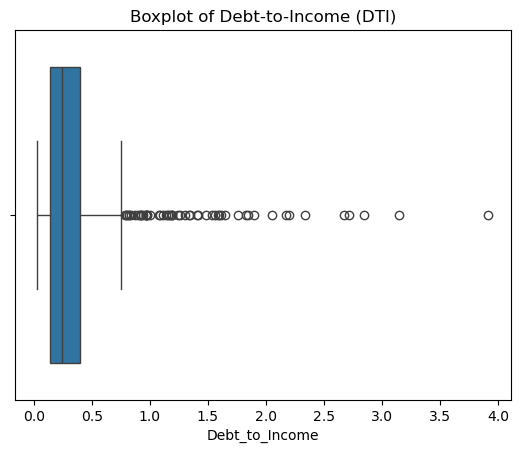

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=data["Debt_to_Income"])
plt.title("Boxplot of Debt-to-Income (DTI)")
plt.show()

In [34]:
data.to_csv("SME_Loan_Portfolio.csv", index=False)